In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
d_df = pd.read_csv("d.csv")
d_df.head()

,stop_from,stop_from_name,stop_to,stop_to_name,depart_from,arrive_to,route_type,is_night,monday,tuesday,wednesday,thursday,friday,saturday,sunday
0,U2991Z301,Hněvice,T58005,Hněvice seř.n.,4:53:00,4:54:30,2,0,1,1,1,1,1,0,0
1,T58005,Hněvice seř.n.,U4610Z301,Záluží,4:54:30,4:56:00,2,0,1,1,1,1,1,0,0
2,U4610Z301,Záluží,U4609Z301,Dobříň,4:56:00,4:59:00,2,0,1,1,1,1,1,0,0
3,U4609Z301,Dobříň,U4608Z301,Roudnice nad Labem,4:59:00,5:03:00,2,0,1,1,1,1,1,0,0
4,U4608Z301,Roudnice nad Labem,U4609Z301,Dobříň,4:36:00,4:38:00,2,0,1,1,1,1,1,0,0


In [3]:
"""
Converting time format from HH:MM:SS to 24hour format
for instance: '27:30:00' -> '03:30:00'
if there is a mistake return NaN
"""
def time_convertation (t:str) -> str:
    try:
        parts = t.split(":")
        h, m, s = map(int, parts)
        h = h % 24
        return f"{h:02d}:{m:02d}:{s:02d}"
    except Exception:
        return np.nan

for col in ["depart_from", "arrive_to"]:
    d_df[col] = d_df[col].astype(str).apply(time_convertation)

d_df[["depart_from", "arrive_to"]].head()

,depart_from,arrive_to
0,04:53:00,04:54:30
1,04:54:30,04:56:00
2,04:56:00,04:59:00
3,04:59:00,05:03:00
4,04:36:00,04:38:00


## Vizualization of the tram network

making a column that contains days of the week, so that we could find the frequency of how many days per week this connection (stop_from -> stop_to ) is active

In [4]:
days_columns = ["monday", "tuesday", "wednesday", "thursday", "friday", "saturday", "sunday"]

d_df["week_frequency"] = d_df[days_columns].sum(axis=1)
d_df[["stop_from_name", "stop_to_name", "week_frequency"]].head()


df_edges = (
    d_df.groupby(["stop_from_name", "stop_to_name"], as_index=False)["week_frequency"]
        .sum()
        .rename(columns={"week_frequency": "weight"})
)

df_edges.head()

,stop_from_name,stop_to_name,weight
0,"AHr Km 11,485",Mstětice,329
1,"AHr Km 11,485","vl.v km 9,980",319
2,Albertov,Botanická zahrada,3113
3,Albertov,Ostrčilovo náměstí,5093
4,Albertov,Výtoň,1700


with the help of Networkx, building directed graph
each row in 'df_edges' represents a directed connection between two stops:
    \n- 'stop_from_name' origin stop
    \n- 'stop_to_name' destination stop
    \n- 'weight' weekly frequency

In [5]:
G = nx.DiGraph()

for _, row in df_edges.iterrows():
    u = row["stop_from_name"]
    v = row["stop_to_name"]
    w = row["weight"]
    G.add_edge(u, v, weight=w) #adding an edge between each pair of vertexes

print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")
#getting information about total number of unique nodes and edges
d_df["route_type"].value_counts()
#identifying categories of transport datas

Number of nodes: 7396
Number of edges: 18467


route_type
3    954268
0    575015
1     56464
2     55672
4       698
7       316
Name: count, dtype: int64

because the original dataset contains diffrent types of transport, we will keep only those that are connected to trams

In [7]:
tram = 0 

# keeping only tram rows
df_tram = d_df[d_df["route_type"] == tram].copy()

#grouping by pairs of stops, but with tram routes
df_tram_edges = (
    df_tram.groupby(["stop_from_name", "stop_to_name"], as_index=False)["week_frequency"]
           .sum() #sum weekly frequencies to find the weight of an edge
           .rename(columns={"week_frequency": "weight"})
)

# building directed graph
G_tram = nx.DiGraph()
# adding weighted edges
for _, row in df_tram_edges.iterrows():
    G_tram.add_edge(row["stop_from_name"], row["stop_to_name"], weight=row["weight"])

print(f"Tram network nodes: {G_tram.number_of_nodes()}, edges: {G_tram.number_of_edges()}")

Tram network nodes: 281, edges: 661


In [10]:
stops = pd.read_csv("stops.txt")
stops.head()
stops.columns

Index(['stop_id', 'stop_name', 'stop_lat', 'stop_lon', 'zone_id', 'stop_url',
       'location_type', 'parent_station', 'wheelchair_boarding', 'level_id',
       'platform_code', 'asw_node_id', 'asw_stop_id'],
      dtype='str')

To obtain a clean list of unique stops, we aggregate the dataset by stop name and compute the average latitude and longitude for each group. This produces one representative coordinate per stop.

In [11]:
stops_agg = (
    stops.groupby("stop_name")[["stop_lat", "stop_lon"]]
         .mean()
         .reset_index()
)

stops_agg.head()

,stop_name,stop_lat,stop_lon
0,"AHr Km 11,485",50.146550,14.731470
1,Albertov,50.067917,14.420798
2,Ametystová,49.988201,14.362216
3,Amforová,50.041778,14.327298
4,Anděl,50.071132,14.403406


In [12]:
df_tram_edges.head()

,stop_from_name,stop_to_name,weight
0,Albertov,Botanická zahrada,3113
1,Albertov,Ostrčilovo náměstí,5093
2,Albertov,Výtoň,1700
3,Anděl,Arbesovo náměstí,4345
4,Anděl,Bertramka,7207


In [13]:
# getting the set of all stops that appear in tram network
tram_stops = set(df_tram_edges["stop_from_name"]) | set(df_tram_edges["stop_to_name"])

# filtering aggregated stops to keeponly those, that belong to tram network
stops_tram = stops_agg[stops_agg["stop_name"].isin(tram_stops)].copy()

# creating a dictionary that maps each stop name to its coordinate
stops_pos = {
    row["stop_name"]: (row["stop_lat"], row["stop_lon"])
    for _, row in stops_tram.iterrows()
}


print(f"Number of stops in tram network with valid coordinates: {len(stops_pos)}")

Number of stops in tram network with valid coordinates: 281


In [14]:
import folium

# initializing an interactive map centered approximately on Prague
mapa = folium.Map(location=[50.08, 14.43], zoom_start=12)

# drawing edges
for _, row in df_tram_edges.iterrows():
    u = row["stop_from_name"]
    v = row["stop_to_name"]

    # drawing only if both stops have valid coordinates
    if u in stops_pos and v in stops_pos:
        lat_u, lon_u = stops_pos[u]
        lat_v, lon_v = stops_pos[v]
        
        folium.PolyLine(
            locations=[(lat_u, lon_u), (lat_v, lon_v)],
            weight=2,      
            opacity=0.7
        ).add_to(mapa)

# drawing nodes
for stop, (lat, lon) in stops_pos.items():
    folium.CircleMarker(
        location=(lat, lon),
        radius=3,
        color="blue",
        fill=True,
        fill_opacity=1,
        popup=stop  # showing name when clicking
    ).add_to(mapa)

mapa

## Centrality

In [15]:
# degree cantrality
deg_centrality = nx.degree_centrality(G_tram)
sorted(deg_centrality.items(), key=lambda x: x[1], reverse=True)[:10]

[('Malostranská', 0.04642857142857143),
 ('Náměstí Bratří Synků', 0.04285714285714286),
 ('Otakarova', 0.04285714285714286),
 ('Anděl', 0.03571428571428571),
 ('Prašný most', 0.03571428571428571),
 ('Vozovna Střešovice', 0.03571428571428571),
 ('Národní divadlo', 0.03571428571428571),
 ('Karlovo náměstí', 0.03214285714285714),
 ('Hradčanská', 0.03214285714285714),
 ('Strossmayerovo náměstí', 0.03214285714285714)]

In [16]:
# betweenneess centrality
bet_centrality = nx.betweenness_centrality(G_tram, weight="weight", normalized=True)
sorted(bet_centrality.items(), key=lambda x: x[1], reverse=True)[:10]

[('Malostranská', 0.37881464413722477),
 ('Jiráskovo náměstí', 0.3693932411674347),
 ('Národní divadlo', 0.34993599590373786),
 ('Staroměstská', 0.3349334357398874),
 ('Čechův most', 0.31121351766513056),
 ('Výtoň', 0.27178699436763953),
 ('Těšnov', 0.2618279569892473),
 ('Chotkovy sady', 0.259715821812596),
 ('Strossmayerovo náměstí', 0.24696620583717357),
 ('Palackého náměstí (nábřeží)', 0.24676139272913467)]

In [28]:
# closeness centrality
clo_centrality = nx.closeness_centrality(G_tram, distance=None)
sorted(clo_centrality.items(), key=lambda x: x[1], reverse=True)[:10]

[('Malostranská', 0.09625300790649707),
 ('Staroměstská', 0.09543285616905249),
 ('Čechův most', 0.09488309047780413),
 ('Strossmayerovo náměstí', 0.0937395379979913),
 ('Právnická fakulta', 0.09317803660565724),
 ('Karlovo náměstí', 0.09293063391968139),
 ('Národní divadlo', 0.09201445941505093),
 ('Dlouhá třída', 0.09186351706036745),
 ('Jiráskovo náměstí', 0.09070294784580499),
 ('Masarykovo nádraží', 0.0901481004507405)]

In [55]:
# making a DataFrame with centralities
centrality_df = pd.DataFrame({
    "stop": list(deg_centrality.keys()),
    "degree": [deg_centrality[s] for s in deg_centrality.keys()],
    "betweenness": [bet_centrality[s] for s in deg_centrality.keys()],
    "closeness": [clo_centrality[s] for s in deg_centrality.keys()],
})

centrality_df.head()

,stop,degree,betweenness,closeness
0,Albertov,0.021429,0.204275,0.083458
1,Botanická zahrada,0.014286,0.011764,0.082889
2,Ostrčilovo náměstí,0.014286,0.187852,0.079455
3,Výtoň,0.021429,0.271787,0.085132
4,Anděl,0.035714,0.210740,0.082547


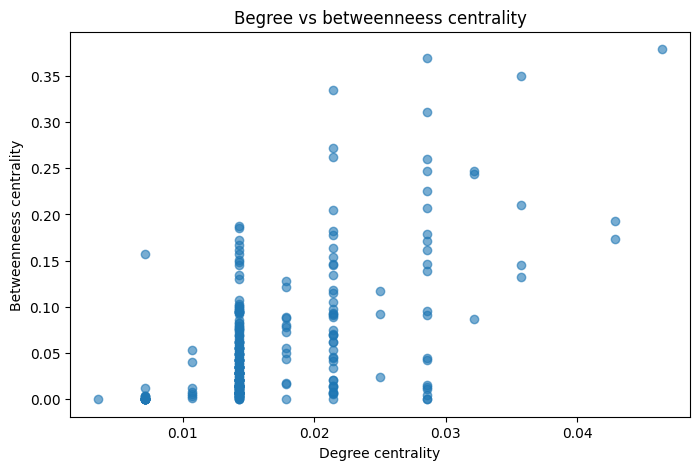

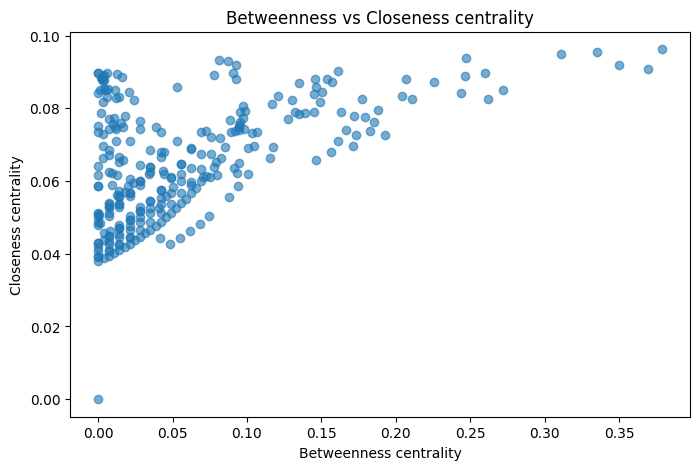

In [53]:
# vizualization difference between degree and betweenness centralizations
plt.figure(figsize = (8,5))
plt.scatter(
    centrality_df["degree"],
    centrality_df["betweenness"],
    alpha = 0.6
)
plt.xlabel("Degree centrality")
plt.ylabel("Betweenneess centrality")
plt.title("Begree vs betweenneess centrality")
plt.show()

# vizualization difference between closeness and betweenness centralizations
plt.figure(figsize=(8,5))
plt.scatter(
    centrality_df["betweenness"],
    centrality_df["closeness"],
    alpha=0.6
)

plt.xlabel("Betweenness centrality")
plt.ylabel("Closeness centrality")
plt.title("Betweenness vs Closeness centrality")

plt.show()

**Summary**

- Degree correlation and betweenness have weak correlation. Highly connected stops are not always key transfer hubs

- Betweenness and closeness are more correlated. Important transfer points tend to be located in the central area

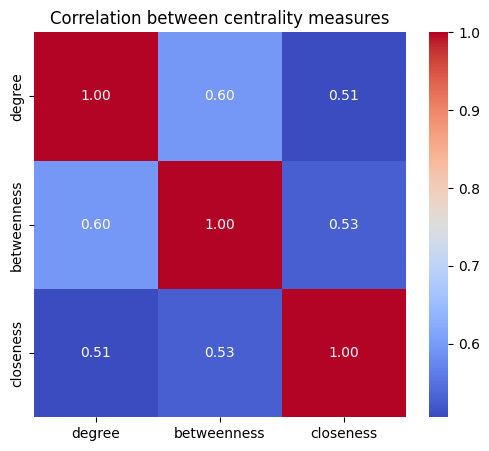

In [54]:
corr = centrality_df[["degree", "betweenness", "closeness"]].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation between centrality measures")
plt.show()

The three centrality measures are not really relayed to each other.
Each of them captures a different aspect of node importance.

- degree - local hubs
- betweenness - transfer bridges
- closeness - global centres

## Betweenness centrality vizualization

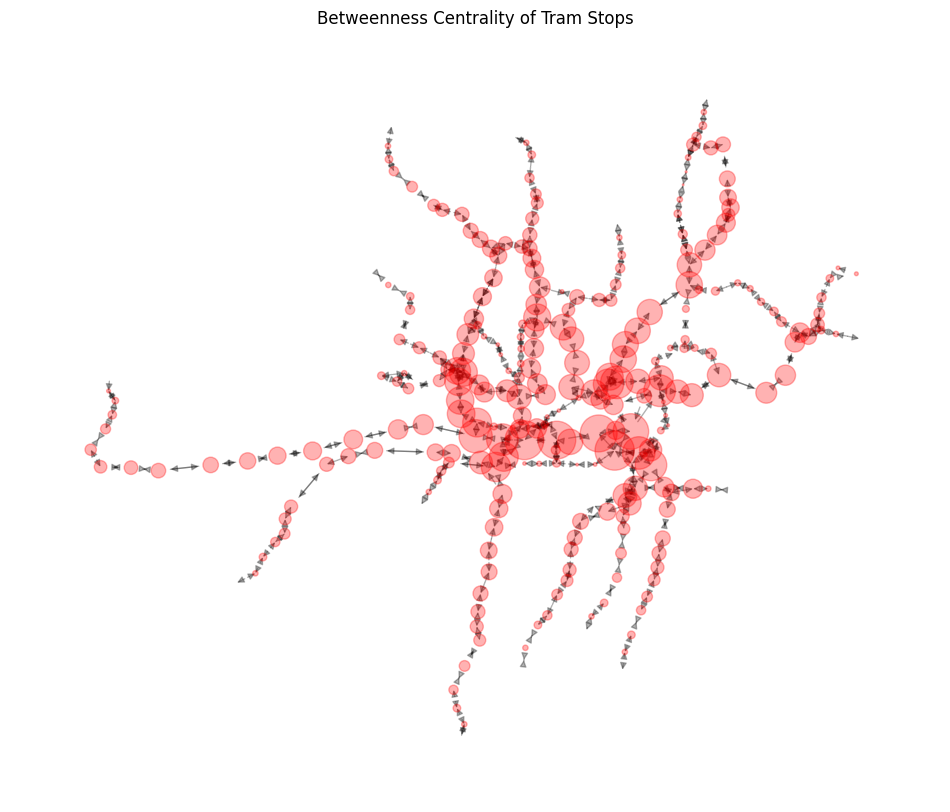

In [62]:
# normalizing betweenness values
max_bet = max(bet_centrality.values())
sizes = [(b / max_bet) * 800 for b in bet_centrality.values()]

plt.figure(figsize=(12, 10))
#making nodes sizes proportional to their betweenness centrality
nx.draw_networkx_nodes(
    G_tram, pos,
    node_size=sizes,
    node_color="red",
    alpha=0.3
)
nx.draw_networkx_edges(G_tram, stops_pos, alpha=0.3)

plt.title("Betweenness Centrality of Tram Stops")
plt.axis("off")
plt.show()

## Questions

**№1** 
Do the busiest tram stops differ between daytime and night-time?

In [63]:
# dividing DataFrame into day and night routes
df_day = d_df[d_df["is_night"] == 0].copy()
df_night = d_df[d_df["is_night"] == 1].copy()

# how many times each stop is reached during the week 
# for daytime
day_arrivals = (
    df_day.groupby("stop_to_name")["week_frequency"]
          .sum()
          .reset_index()
          .rename(columns={"week_frequency": "day_arrivals"})
)
# for nighttime
night_arrivals = (
    df_night.groupby("stop_to_name")["week_frequency"]
            .sum()
            .reset_index()
            .rename(columns={"week_frequency": "night_arrivals"})
)

# merging results into one table
arrivals_compare = day_arrivals.merge(night_arrivals, on="stop_to_name", how="outer").fillna(0)

# top 10 busiest stops during day and night
day_top10 = arrivals_compare.sort_values("day_arrivals", ascending=False).head(10)
night_top10 = arrivals_compare.sort_values("night_arrivals", ascending=False).head(10)

day_top10, night_top10

(         stop_to_name  day_arrivals  night_arrivals
 4               Anděl       33125.0          1120.0
 1819  Karlovo náměstí       30295.0          2230.0
 2857          Lihovar       24343.0           287.0
 4180         Palmovka       24343.0           735.0
 1533    I. P. Pavlova       23912.0          1730.0
 3066     Malostranská       23617.0           366.0
 3964    Národní třída       23458.0          1156.0
 3962  Národní divadlo       23194.0          1156.0
 4023           Ohrada       22861.0           890.0
 7333       Želivského       22455.0           553.0,
             stop_to_name  day_arrivals  night_arrivals
 2701            Lazarská       15354.0          2303.0
 1819     Karlovo náměstí       30295.0          2230.0
 1533       I. P. Pavlova       23912.0          1730.0
 6413   Václavské náměstí       15354.0          1444.0
 6232           Vodičkova       15354.0          1444.0
 1656          Jindřišská       15354.0          1444.0
 3122  Masarykovo nádraž

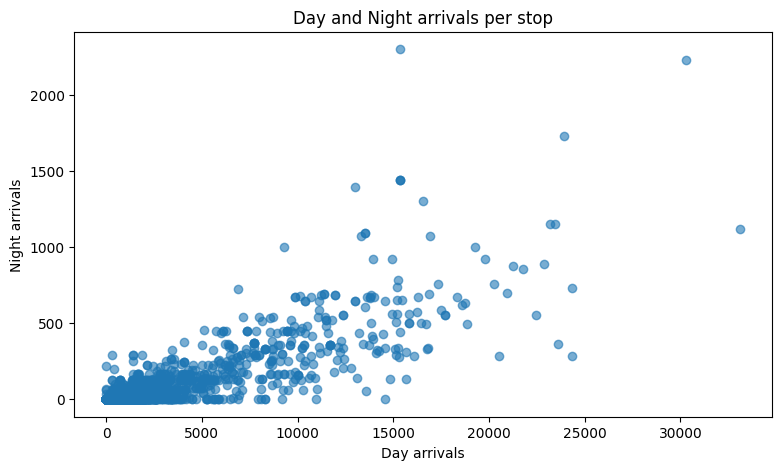

In [67]:
plt.figure(figsize = (9,5))

plt.scatter(
    arrivals_compare["day_arrivals"],
    arrivals_compare["night_arrivals"],
    alpha = 0.6
)

plt.xlabel("Day arrivals")
plt.ylabel("Night arrivals")
plt.title("Day and Night arrivals per stop"
plt.show()

The scatter plot visualizes the relationship between weekly daytime arrivals and nighttime arrivals for each stop. Most points cluster near the horizontal axis, indicating that a large number of stops receive very few night-time arrivals compared to daytime.

Only a small number of stops have high nighttime activity. Meanwhile, daytime arrivals are spread out across many more stops.

This shows that the busiest stops during the day are not necessarily the busiest at night. In general, the night network is more concentrated and less dispersed than the daytime one.

**№2** How do the busiest stop differ between working days and weekdays

In [70]:
# finding frequencies for working days and weekends
d_df["workday_freq"] = d_df[["monday", "tuesday", "wednesday", "thursday", "friday"]].sum(axis=1)
d_df["weekend_freq"] = d_df[["saturday", "sunday"]].sum(axis=1)

# aggregating working days and weekends for each stop
workday_arrivals = (
    d_df.groupby("stop_to_name")["workday_freq"]
        .sum()
        .reset_index()
        .rename(columns={"workday_freq": "workday_arrivals"})
)

weekend_arrivals = (
    d_df.groupby("stop_to_name")["weekend_freq"]
        .sum()
        .reset_index()
        .rename(columns={"weekend_freq": "weekend_arrivals"})
)

# merging into one table
stops_week = workday_arrivals.merge(weekend_arrivals, on="stop_to_name", how="outer").fillna(0)

stops_week.head()

,stop_to_name,workday_arrivals,weekend_arrivals
0,"AHr Km 11,485",491,157
1,Albertov,8820,1086
2,Ametystová,155,38
3,Amforová,2695,603
4,Anděl,29735,4510


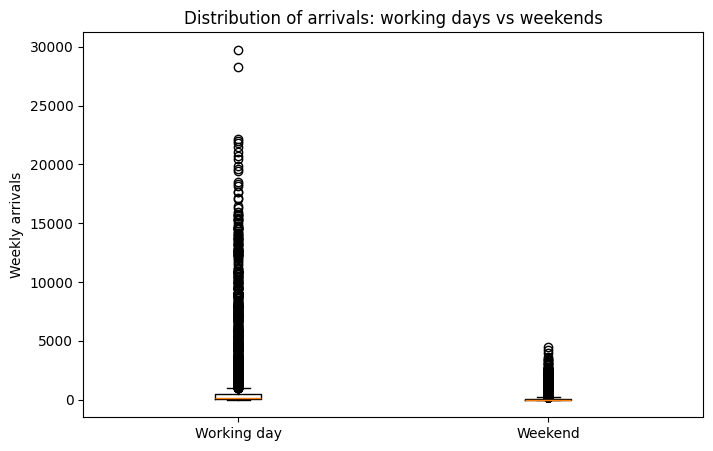

In [72]:
plt.figure(figsize = (8,5))
plt.boxplot([stops_week["workday_arrivals"], stops_week["weekend_arrivals"]],
           tick_labels = ["Working day", "Weekend"])
plt.title("Distribution of arrivals: working days vs weekends")
plt.ylabel("Weekly arrivals")
plt.show()

The boxplot shows a difference between working days and weekends arrival distributions.

Working days have much higher median number of arrivals and more extreme outliers.

Weekends activity is much lower. The median is smaller, distribution is more compact and concentrated at low values.

**№3** Which tram stops are the most important bridges nodes in the largest component of tram network, according to betweenness centrality

In [74]:
# betweenness centrality on the largest tram component
bet_centrality_tram = nx.betweenness_centrality(G_tram, weight="weight", normalized=True)

# converting the centrality dictionary into a DataFrame
bet_tram_df = (
    pd.DataFrame({
        "stop": list(bet_centrality_tram.keys()),
        "betweenness": list(bet_centrality_tram.values())
    })
    .sort_values("betweenness", ascending=False)
)

bet_tram_df.head(10)

,stop,betweenness
78,Malostranská,0.378815
159,Jiráskovo náměstí,0.369393
161,Národní divadlo,0.349936
219,Staroměstská,0.334933
98,Čechův most,0.311214
3,Výtoň,0.271787
59,Těšnov,0.261828
76,Chotkovy sady,0.259716
97,Strossmayerovo náměstí,0.246966
162,Palackého náměstí (nábřeží),0.246761


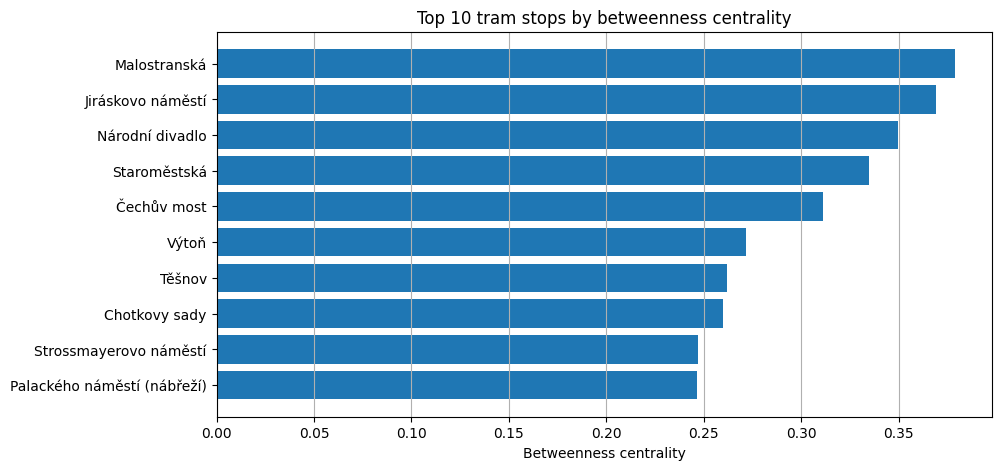

In [29]:
top10 = bet_tram_df.head(10)

plt.figure(figsize=(10, 5))
plt.barh(top10["stop"], top10["betweenness"])
plt.gca().invert_yaxis()
plt.xlabel("Betweenness centrality")
plt.title("Top 10 tram stops by betweenness centrality")
plt.grid(True, axis="x")
plt.show()

The bar chart reveals that tram stops with the highest betweenness centrality are located in the historical center of Prague - most notably Malostranska, Jiravskeho namesti, Narodni divadlo and Staromestska

In summary, betweenness centrality highlights the strategic importance of central Prague stops and their roles aas key connectors in tram system

## Conclusion of the work

During the process of homework, I occasionally used help of ChatGPT as a supporting tool, especially it helped to make a beautiful vizualization of graph in a real map, sometimes helped me resolve the issues I had in the code etc.